# Disease-associated imputation

Applies the SVC model trained on the Xenium mouse brain dataset, without retraining, to matched
WT and P301S tauopathy mouse brain sections profiled with the Xenium Prime 5K panel, and
compares the predicted subcellular localization of the imputed genes between the two genotypes.

Reads

- `test_xenium_mouse_brain_tau.npz`, `gene_names.txt` — the target pair, one section per genotype
- `train_xenium_mouse_brain.npz`, `gene_names.txt`, `gene2vec_weight_xenium_mouse_brain.npy`
- `checkpoint_Xenium_mouse_brain.pth` — the released checkpoint, from `../../../checkpoints`

Writes

- `pred_impute_tau.npz` — by `xenium_mouse_brain/impute.py`

In [1]:
import os
import sys
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from matplotlib.colors import LinearSegmentedColormap
from scipy.stats import false_discovery_control, mannwhitneyu

warnings.filterwarnings('ignore')

SVC_ROOT = Path(os.environ.get('SVC_ROOT', '../../..'))   # github.com/aster-ww/SVC
sys.path.insert(0, str(SVC_ROOT))
from svc.losses import BACKGROUND_PIXELS
from svc.metrics import distance_to_center

foreground = np.ones((12, 12), bool)
for _row, _column in BACKGROUND_PIXELS:
    foreground[_row, _column] = False

DATA_ROOT = Path(os.environ.get('SVC_DATA_ROOT', '../../../data'))
DATA_DIR = DATA_ROOT / 'xenium_mouse_brain_tau'
CKPT_DIR = Path('../../../checkpoints')
OUT_DIR = Path('../../../output/xenium_mouse_brain_tau')

## Imputation

84 genes are present in the training panel but absent from the measured target panel. They are
masked at input and predicted from the 144 observed genes, the morphology and the spatial
neighborhood.

In [2]:
!python {SVC_ROOT}/xenium_mouse_brain/impute.py --data-root {DATA_ROOT} --dataset xenium_mouse_brain_tau --ckpt {CKPT_DIR}/checkpoint_Xenium_mouse_brain.pth --out {OUT_DIR}/pred_impute_tau.npz

144 measured / 84 imputed of 228 genes
48127 cells | cell median over the measured genes, on the training cells = 220.0
loaded epoch 149
saved ../../../output/xenium_mouse_brain_tau/pred_impute_tau.npz  (48127, 84, 12, 12)


## Differential subcellular localization

Focusing on Micro-PVM cells and astrocytes, genes with at least three predicted transcripts in
at least 20 cells in both WT and P301S samples are retained. For each retained gene, the
predicted per-cell relative distance to the nuclear center is compared between genotypes with a
two-sided Mann-Whitney U test, followed by Benjamini-Hochberg correction across genes within
each cell type.

In [3]:
CELL_TYPES = ['Micro-PVM', 'Astro']
MIN_TRANSCRIPTS = 3
MIN_CELLS = 20

target = np.load(DATA_DIR / 'test_xenium_mouse_brain_tau.npz', allow_pickle=True)
cell_type = target['identity'].astype(str)
genotype = target['arm_id']

imputed = np.load(OUT_DIR / 'pred_impute_tau.npz', allow_pickle=True)
prediction = imputed['prediction'].astype(np.float32)
genes = list(imputed['genes'])

counts = prediction.sum(axis=(-1, -2))
distance = distance_to_center(prediction)

screen = {}
for kind in CELL_TYPES:
    wild = (cell_type == kind) & (genotype == 0)
    transgenic = (cell_type == kind) & (genotype == 1)
    detected = counts >= MIN_TRANSCRIPTS

    eligible = []
    for j, gene in enumerate(genes):
        a, b = wild & detected[:, j], transgenic & detected[:, j]
        if a.sum() < MIN_CELLS or b.sum() < MIN_CELLS:
            continue
        eligible.append((gene, np.median(distance[b, j]) - np.median(distance[a, j]),
                         mannwhitneyu(distance[a, j], distance[b, j],
                                      alternative='two-sided').pvalue,
                         int(a.sum()), int(b.sum())))
    corrected = false_discovery_control([e[2] for e in eligible], method='bh')
    screen.update({(kind, e[0]): q for e, q in zip(eligible, corrected)})

    print('%-10s %2d of %d genes eligible' % (kind, len(eligible), len(genes)))
    for (gene, delta, p, n_wild, n_tg), fdr in sorted(zip(eligible, corrected), key=lambda r: r[1]):
        if fdr < 0.05:
            print('    %-8s %+.5f  FDR = %.1e  n = (%d, %d)'
                  % (gene, delta, fdr, n_wild, n_tg))

Micro-PVM   5 of 84 genes eligible
    Laptm5   +0.01314  FDR = 4.1e-04  n = (132, 315)
    Kctd12   +0.01763  FDR = 4.0e-03  n = (37, 113)
Astro      11 of 84 genes eligible
    Clmn     -0.00979  FDR = 4.6e-04  n = (298, 384)


## *Laptm5* in Micro-PVM cells

*Laptm5* shifted away from the nucleus in P301S samples, with a median increase in nuclear
distance of 0.0131.

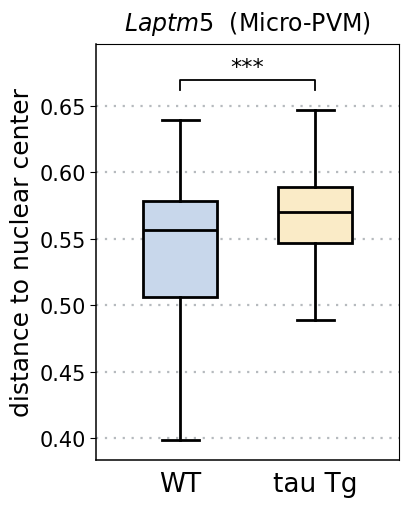

Laptm5 in Micro-PVM | WT n = 132 median 0.5568 | tau Tg n = 315 median 0.5699 | +0.01314  FDR = 4.1e-04


In [4]:
GENE, KIND = 'Laptm5', 'Micro-PVM'
BOX_FILL = ['#C8D7EB', '#FAEBC7']

column = genes.index(GENE)
keep = (cell_type == KIND) & (counts[:, column] >= MIN_TRANSCRIPTS)
wild = distance[keep & (genotype == 0), column]
transgenic = distance[keep & (genotype == 1), column]
fdr = screen[(KIND, GENE)]
stars = '***' if fdr < 1e-3 else '**' if fdr < 1e-2 else '*' if fdr < 0.05 else 'n.s.'

fig, ax = plt.subplots(figsize=(3.9, 5.4))
ax.set_axisbelow(True)
ax.grid(axis='y', color='#b6babe', ls=(0, (1, 3)), lw=1.6)
box = ax.boxplot([wild, transgenic], positions=[0, 1], widths=0.55, showfliers=False,
                 patch_artist=True, zorder=3, medianprops=dict(color='black', lw=2.0),
                 whiskerprops=dict(color='black', lw=2.0), capprops=dict(color='black', lw=2.0))
for patch, color in zip(box['boxes'], BOX_FILL):
    patch.set(facecolor=color, edgecolor='black', linewidth=2.0)

low = min(w.get_ydata().min() for w in box['whiskers'])
high = max(w.get_ydata().max() for w in box['whiskers'])
span = high - low
ax.set_ylim(low - span * 0.06, high + span * 0.20)
tick, bar = span * 0.030, high + span * 0.06
ax.plot([0, 0, 1, 1], [bar, bar + tick, bar + tick, bar], lw=1.3, color='black', zorder=4)
ax.text(0.5, bar + tick * 1.35, stars, ha='center', va='bottom', fontsize=16, zorder=4)

ax.set_xticks([0, 1])
ax.set_xticklabels(['WT', 'tau Tg'])
ax.set_xlim(-0.62, 1.62)
ax.set_ylabel('distance to nuclear center', fontsize=18)
ax.set_title('$\\it{%s}$  (%s)' % (GENE, KIND), fontsize=17, pad=10)
ax.tick_params(axis='y', labelsize=15, direction='out', length=4)
ax.tick_params(axis='x', labelsize=19, length=0, pad=8)
for side in ('left', 'bottom'):
    ax.spines[side].set_linewidth(1.1)
plt.show()

print('%s in %s | WT n = %d median %.4f | tau Tg n = %d median %.4f | %+.5f  FDR = %.1e'
      % (GENE, KIND, len(wild), np.median(wild), len(transgenic), np.median(transgenic),
         np.median(transgenic) - np.median(wild), fdr))

The difference in the predicted subcellular distributions between tau Tg and WT cells,
averaged over cells as the per-pixel change in mass fraction; each cell's map is normalized to
sum to one before averaging.

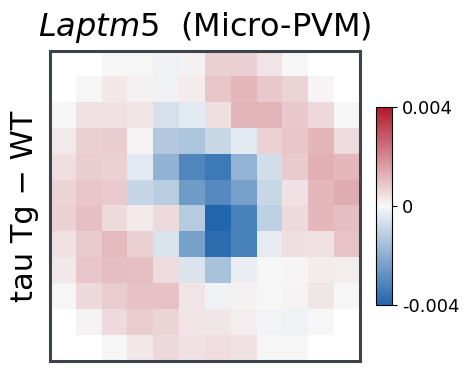

In [5]:
CAP = 0.004

maps = prediction[keep][:, column].reshape(-1, 144)
share = maps / np.maximum(maps.sum(1, keepdims=True), 1e-12)
arm = genotype[keep]
difference = np.where(foreground.ravel(),
                      share[arm == 1].mean(0) - share[arm == 0].mean(0), np.nan)

divergent = LinearSegmentedColormap.from_list('div', ['#2166ac', '#f7f7f7', '#b2182b']).copy()
divergent.set_bad('white')

side = 3.1
fig = plt.figure(figsize=(4.3, 3.9))
ax = fig.add_axes([0.06 / 4.3, 0.10 / 3.9, side / 4.3, side / 3.9])
image = ax.imshow(difference.reshape(12, 12), cmap=divergent, vmin=-CAP, vmax=CAP)
ax.set_xticks([])
ax.set_yticks([])
for spine in ax.spines.values():
    spine.set_color('#3d434a')
    spine.set_linewidth(2.2)
ax.set_title('$\\it{%s}$  (%s)' % (GENE, KIND), fontsize=23, pad=11)
ax.set_ylabel('tau Tg − WT', fontsize=22, labelpad=8)
bar = fig.add_axes([(0.06 + side + 0.16) / 4.3, (0.10 + side * 0.18) / 3.9,
                    0.16 / 4.3, side * 0.64 / 3.9])
colors = fig.colorbar(image, cax=bar, ticks=[-CAP, 0, CAP])
colors.ax.set_yticklabels(['%g' % -CAP, '0', '%g' % CAP], fontsize=13)
plt.show()